# CelebA-HQ Data Loading

This notebook loads the high-resolution CelebA-HQ dataset and formats it to match the codebase conventions:
- `coords`: `(N, 2)` — pixel grid coordinates in `[0, 1]²`
- `images`: `(B, N, 3)` — batch of B images with RGB channel values at each of the N grid points

In [41]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


## Configuration

Set the resolution to downsample images to and the batch size.
The full 1024×1024 CelebA-HQ images give N = 1,048,576 points per image.
Resize to a smaller resolution for tractable experiments.

In [42]:
RESOLUTION = 128   # resize images to RESOLUTION x RESOLUTION
BATCH_SIZE = 8     # number of images per batch
N_IMAGES   = 32    # total images to pre-load (used for batch visualisation + PCA)

## Create `CelebADataset` and extract `coords`

`CelebADataset` pre-loads `N_IMAGES` images and builds the full `H×W` pixel-grid
internally.  Calling `dataset(seed)` returns `(coords, signal)` for image `seed % n_images`.

In [43]:
from infidictionary.datasets.celeba import CelebADataset

H = W = RESOLUTION
N = H * W

dataset = CelebADataset(
    resolution=RESOLUTION,
    n_images=N_IMAGES,
    drop_fraction=0.0,
    device=device,
)

coords, _ = dataset(0)   # (N, 2)  full pixel-grid coordinates in [0, 1]²

print(f'coords shape : {coords.shape}')
print(f'coords range : [{coords.min():.4f}, {coords.max():.4f}]')

coords shape : torch.Size([16384, 2])
coords range : [0.0039, 0.9961]


## Build an Image Batch: `images` of shape `(B, N, 3)`

Call `dataset(seed)` for each image index; stack the returned signals into a batch.

In [44]:
images = torch.stack([dataset(i)[1] for i in range(BATCH_SIZE)], dim=0)  # (B, N, 3)

print(f'images shape : {images.shape}')
print(f'images dtype : {images.dtype}')
print(f'images range : [{images.min():.4f}, {images.max():.4f}]')

images shape : torch.Size([8, 16384, 3])
images dtype : torch.float32
images range : [0.0000, 1.0000]


## Visualisation

Reconstruct images from the `(B, N, 3)` signal tensor and display them.

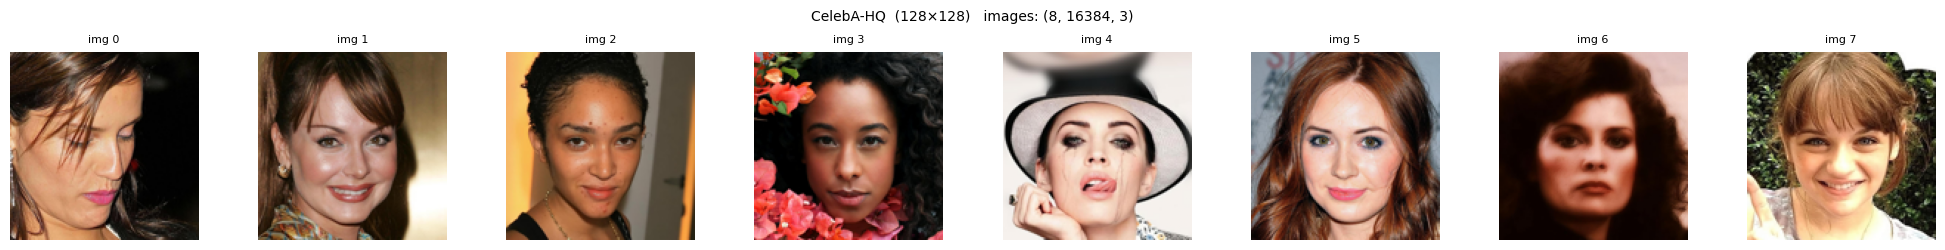

In [45]:
def signal_to_img(signal: torch.Tensor, h: int, w: int) -> np.ndarray:
    """Convert a (N, 3) signal tensor back to a (H, W, 3) uint8 numpy array.

    The dataset stores signals with y=0 at the bottom (math convention), so we
    flip vertically before passing to imshow (which expects y=0 at the top).
    """
    img = signal.detach().cpu().reshape(h, w, 3).numpy()
    img = img[::-1]   # flip rows: bottom → top for imshow
    return np.clip(img, 0.0, 1.0)


n_show = min(BATCH_SIZE, 8)
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 2.5))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(signal_to_img(images[i], H, W))
    ax.set_title(f'img {i}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'CelebA-HQ  ({H}×{W})   images: {tuple(images.shape)}', fontsize=10)
plt.tight_layout()
plt.show()

## Irregular-Grid Pullback Experiment

Take two images, randomly drop a fraction of pixels to produce an irregular grid, then pull both signals back through a randomly-initialised `EulerianIsometry` (200 steps). We verify the isometry property by comparing inner products before and after the pullback, and we visualise the pulled-back images.

In [46]:
# ── 1. Pick two images and build an irregular (sparse) grid ──────────────────

DROP_FRACTION = 0.9   # fraction of pixels to discard
IMG_A, IMG_B = 0, 1  # indices into the dataset

torch.manual_seed(42)

# Fetch full-grid images via __call__
full_coords, signal_a = dataset(IMG_A)   # (N_full, 2), (N_full, 3)
_,           signal_b = dataset(IMG_B)   # (N_full, 3)

N_full = full_coords.shape[0]
N_keep = int(N_full * (1 - DROP_FRACTION))

# Random subset of pixel indices (no replacement)
keep_idx = torch.randperm(N_full, device=device)[:N_keep]  # (N_keep,)

# Sparse coords and signals — shapes (N_keep, 2) and (2, N_keep, 3)
sparse_coords    = full_coords[keep_idx]                                         # (N_keep, 2)
sparse_logabsdet = torch.zeros(N_keep, device=device)
sparse_signals   = torch.stack([signal_a[keep_idx], signal_b[keep_idx]], dim=0) # (2, N_keep, 3)

print(f"Full grid  : {N_full:,} pixels")
print(f"Sparse grid: {N_keep:,} pixels  ({DROP_FRACTION*100:.0f}% dropped)")
print(f"sparse_coords  : {tuple(sparse_coords.shape)}")
print(f"sparse_signals : {tuple(sparse_signals.shape)}")

Full grid  : 16,384 pixels
Sparse grid: 1,638 pixels  (90% dropped)
sparse_coords  : (1638, 2)
sparse_signals : (2, 1638, 3)


In [47]:
# ── 2. Build a randomly-initialised EulerianIsometry (200 steps) ─────────────

from functools import partial
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.utils import TimeEvolvingField, MLPNeuralField

# Mirror the architecture from conf/neural_isometry/eulerian.yaml
# but with channels_dim=3 for RGB
mlp_partial = partial(
    MLPNeuralField,
    hidden_dims={"a": 16, "b": 32, "c": 64, "d": 32},
    activation=torch.nn.ReLU,
)

def scalar_field_partial(coords_dim: int, output_dim: int) -> TimeEvolvingField:
    return TimeEvolvingField(base_field_partial=mlp_partial, coords_dim=coords_dim, output_dim=output_dim)

isometry = EulerianIsometry(
    coords_dim=2,
    channels_dim=3,
    scalar_field_partial=scalar_field_partial,
).to(device)

# Set the number of integration steps, then fix a deterministic tspan via eval()
isometry.shuffle_model_state(num_steps=200)
isometry.eval()   # sets tspan = linspace(0, 1, 200) and freezes BN/dropout if any

print(isometry)
print(f"\ntspan shape : {isometry.tspan.shape}")
print(f"tspan range : [{isometry.tspan.min():.4f}, {isometry.tspan.max():.4f}]")

EulerianIsometry(
  (function_field): TimeEvolvingField(
    (time_embedding): SinusoidalTimeEmbedding()
    (time_evolving_field): MLPNeuralField(
      (network): Sequential(
        (0): Linear(in_features=18, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=64, bias=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=32, bias=True)
        (7): ReLU()
        (8): Linear(in_features=32, out_features=3, bias=True)
      )
    )
  )
)

tspan shape : torch.Size([200])
tspan range : [0.0000, 1.0000]


In [48]:
# ── 3. Pullback and inner-product comparison ──────────────────────────────────

from infidictionary.utils import pairwise_inner_product

with torch.no_grad():
    _, _, pulled_signals = isometry.pullback(
        tgt_coords=sparse_coords,
        tgt_logabsdet=sparse_logabsdet,
        tgt_field=sparse_signals,
        start_time=0.0,
        end_time=1.0,
    )

# Inner-product matrix  (2×2)  before and after pullback
ip_before = pairwise_inner_product(sparse_signals,  sparse_signals,  sparse_logabsdet)
ip_after  = pairwise_inner_product(pulled_signals,  pulled_signals,  sparse_logabsdet)

labels = [f"img {IMG_A}", f"img {IMG_B}"]
print("Inner-product matrix  BEFORE pullback:")
print(f"  {'':10s} {labels[0]:>12s} {labels[1]:>12s}")
for i, row_lbl in enumerate(labels):
    print(f"  {row_lbl:10s} {ip_before[i,0].item():12.6f} {ip_before[i,1].item():12.6f}")

print("\nInner-product matrix  AFTER pullback:")
print(f"  {'':10s} {labels[0]:>12s} {labels[1]:>12s}")
for i, row_lbl in enumerate(labels):
    print(f"  {row_lbl:10s} {ip_after[i,0].item():12.6f} {ip_after[i,1].item():12.6f}")

print("\nAbsolute difference (should be ~0 for a true isometry):")
print(f"  {(ip_before - ip_after).abs().max().item():.2e}  (max entry)")

Inner-product matrix  BEFORE pullback:
                    img 0        img 1
  img 0          0.542868     0.418337
  img 1          0.418337     0.713371

Inner-product matrix  AFTER pullback:
                    img 0        img 1
  img 0          0.542869     0.418337
  img 1          0.418337     0.713369

Absolute difference (should be ~0 for a true isometry):
  1.43e-06  (max entry)


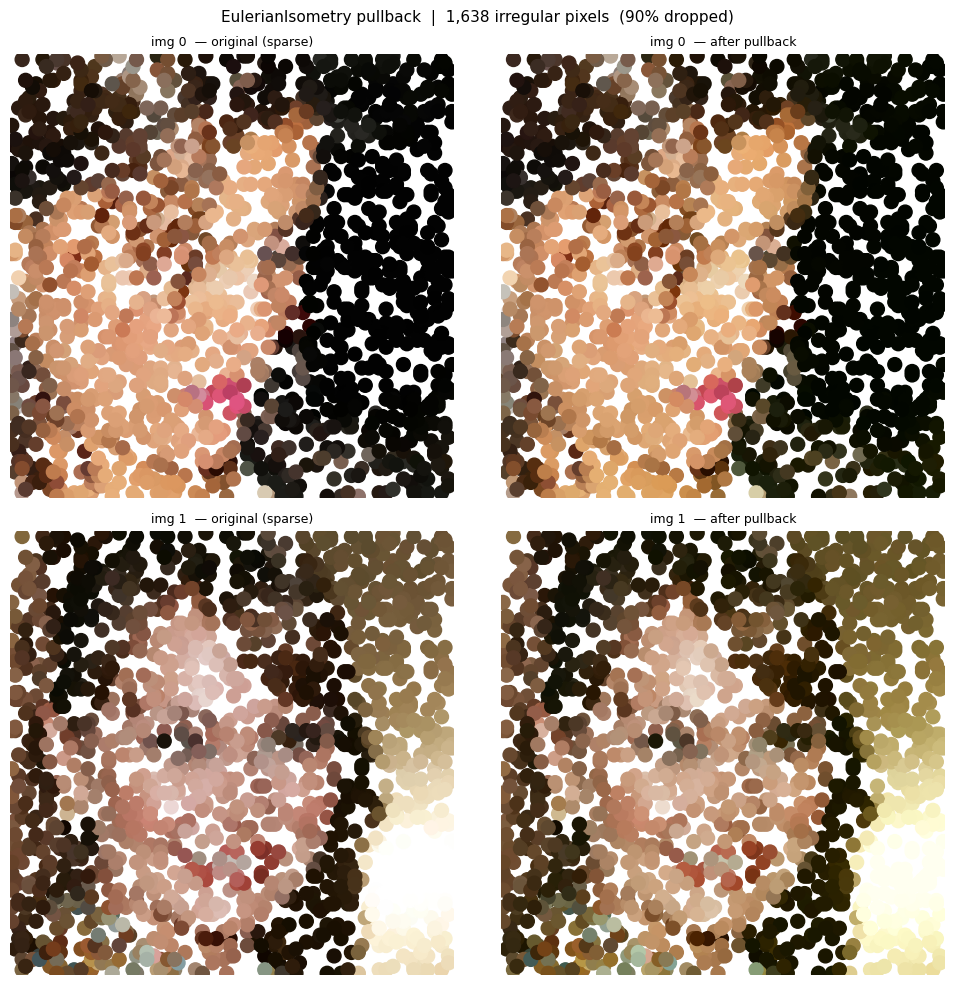

In [49]:
# ── 4. Visualisation: original vs pulled-back on the irregular grid ───────────

coords_np  = sparse_coords.detach().cpu().numpy()          # (N_keep, 2)
before_np  = sparse_signals.detach().cpu().numpy()         # (2, N_keep, 3)
after_np   = pulled_signals.detach().cpu().numpy()         # (2, N_keep, 3)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = [
    (f"img {IMG_A}  — original (sparse)",  f"img {IMG_A}  — after pullback"),
    (f"img {IMG_B}  — original (sparse)",  f"img {IMG_B}  — after pullback"),
]

for row, (img_orig, img_pb, (t_orig, t_pb)) in enumerate(
    zip(before_np, after_np, titles)
):
    for col, (vals, title) in enumerate([(img_orig, t_orig), (img_pb, t_pb)]):
        ax = axes[row][col]
        # Clamp to [0, 1] and scatter-plot each point coloured by its RGB value
        rgb = np.clip(vals, 0.0, 1.0)                    # (N_keep, 3)
        ax.scatter(
            coords_np[:, 0],
            coords_np[:, 1],                        # flip y: origin top-left
            c=rgb,
            s=100.0,
            rasterized=True,
        )
        ax.set_title(title, fontsize=9)
        ax.set_aspect("equal")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis("off")

plt.suptitle(
    f"EulerianIsometry pullback  |  {N_keep:,} irregular pixels  ({DROP_FRACTION*100:.0f}% dropped)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## PCA Baseline (Eigenfaces)

Classic PCA on CelebA faces:
1. Collect batches → put each image on a regular `H×W` pixel grid via BICUBIC interpolation (already done by `pil_to_signal`).
2. Stack into a data matrix `X` of shape `(M, D)` where `D = N × 3`.
3. Compute the **mean face**, subtract it, then run **SVD** to extract eigenfaces.


In [50]:
# Use __call__ to gather all images on CPU for SVD
signals = [dataset(i)[1].cpu() for i in range(N_IMAGES)]
X_flat  = torch.stack(signals, dim=0).reshape(N_IMAGES, N * 3)   # (M, D)
M, D    = X_flat.shape

print(f'Data matrix X : {tuple(X_flat.shape)}  (M={M} images, D={D} = {N} pixels × 3 channels)')

Data matrix X : (32, 49152)  (M=32 images, D=49152 = 16384 pixels × 3 channels)


In [51]:
# ── Mean face + centred data ──────────────────────────────────────────────────
mean_face_flat = X_flat.mean(dim=0)          # (D,)
X_centered     = X_flat - mean_face_flat     # (M, D)

# ── SVD:  X_centered = U @ diag(S) @ Vh ──────────────────────────────────────
# With full_matrices=False:
#   U  : (M, K)  — left singular vectors (image coefficients)
#   S  : (K,)    — singular values  (K = min(M, D))
#   Vh : (K, D)  — right singular vectors → principal components (eigenfaces)
U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

print(f'U  : {tuple(U.shape)}')
print(f'S  : {tuple(S.shape)}')
print(f'Vh : {tuple(Vh.shape)}  ← each row is an eigenface (D={D})')

# Explained variance (proportional to S²)
explained_var = (S ** 2) / (S ** 2).sum()
cumulative_var = explained_var.cumsum(dim=0)
for k in [1, 5, 10, 20, 50]:
    if k <= len(cumulative_var):
        print(f'  Top-{k:3d} PCs explain {cumulative_var[k-1].item()*100:.1f}% of variance')


U  : (32, 32)
S  : (32,)
Vh : (32, 49152)  ← each row is an eigenface (D=49152)
  Top-  1 PCs explain 28.8% of variance
  Top-  5 PCs explain 62.4% of variance
  Top- 10 PCs explain 77.7% of variance
  Top- 20 PCs explain 92.5% of variance


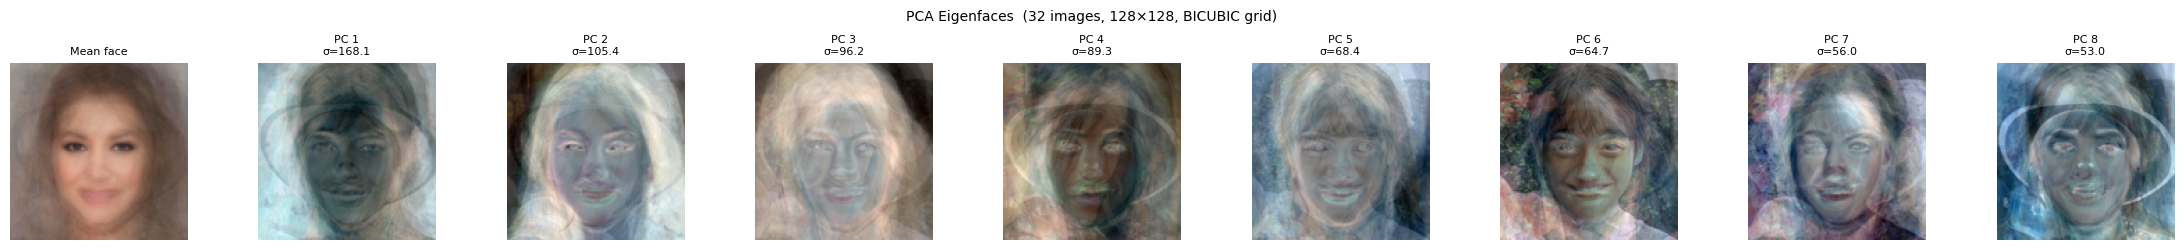

In [52]:
# ── Visualise: mean face + top eigenfaces ────────────────────────────────────
K_show = 8   # number of eigenfaces to display

mean_img   = mean_face_flat.reshape(N, 3)      # (N, 3)
eigenfaces = Vh[:K_show].reshape(K_show, N, 3) # (K_show, N, 3)

def normalise_for_display(x: torch.Tensor) -> torch.Tensor:
    """Shift and scale a (N, 3) tensor to [0, 1] for imshow."""
    x = x - x.min()
    return x / (x.max() + 1e-8)

fig, axes = plt.subplots(1, K_show + 1, figsize=(2.5 * (K_show + 1), 2.5))

# Mean face (already in [0, 1])
axes[0].imshow(signal_to_img(mean_img, H, W))
axes[0].set_title('Mean face', fontsize=8)
axes[0].axis('off')

# Eigenfaces (normalised to [0, 1] for display)
for i in range(K_show):
    axes[i + 1].imshow(signal_to_img(normalise_for_display(eigenfaces[i]), H, W))
    axes[i + 1].set_title(f'PC {i+1}\nσ={S[i]:.1f}', fontsize=8)
    axes[i + 1].axis('off')

plt.suptitle(f'PCA Eigenfaces  ({M} images, {H}×{W}, BICUBIC grid)', fontsize=10)
plt.tight_layout()
plt.show()


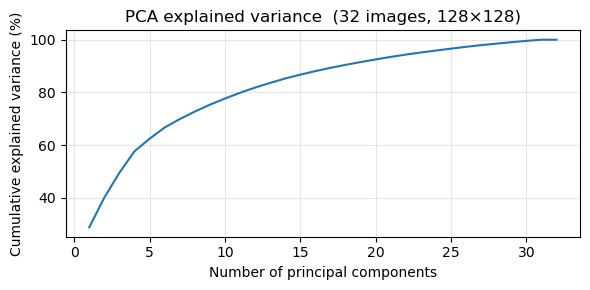

In [53]:
# ── Explained variance curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var.numpy() * 100)
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title(f'PCA explained variance  ({M} images, {H}×{W})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
